# Financial Inclusion in East Africa  -  Data Mining Project
**Author:** Carlos HARERIMANA  |  **Student ID:** 101200  
**Course:** MSDA 9213  -  Data Mining  \
**Task:** Predict bank-account ownership (classification) and segment respondents (clustering) using a real EAC dataset.

**Dataset:** Financial Inclusion survey (FinScope), 23,524 individuals across **Kenya, Rwanda, Tanzania, Uganda**  -  all EAC members.  
**Source:** [Kaggle  -  Financial Dataset (Enock Mokua)](https://www.kaggle.com/datasets/enockmokua/financial-dataset/data)

**Pipeline (exam steps):**
1. Dataset selection
2. Data cleaning
3. EDA
4. Objectives
5. Modeling  -  LDA, QDA, KNN, Neural Network (deep learning)
6. Evaluation and comparison
7. Improvement (SMOTE)
8. Before/after comparison

Plus unsupervised: **K-Means** clustering.

## 0. Imports

In [1]:
import numpy as np, pandas as pd, warnings, os
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis,
                                           QuadraticDiscriminantAnalysis)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    silhouette_score, RocCurveDisplay)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# Reproducibility constants (fixed random seed reused everywhere randomness occurs)
RANDOM_SEED = 47
tf.random.set_seed(RANDOM_SEED)   # deep-learning (TensorFlow/Keras) operations
np.random.seed(RANDOM_SEED)       # NumPy-based operations

# Colour palette (defined once, reused across all plots)
PRIMARY = "#38a"   # blue
ACCENT  = "#4a7"   # green
NEG     = "#c44"   # red
WARN    = "#a83"   # brown / amber
MUTED   = "#bbb"   # grey (used for 'before' bars)

I0000 00:00:1788531155.534696   39080 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788531155.536995   39080 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788531157.266257   39080 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788531157.267686   39080 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Step 1  -  Dataset
Source: [Kaggle  -  Financial Dataset (Enock Mokua)](https://www.kaggle.com/datasets/enockmokua/financial-dataset/data)

The dataset supports **both** required task families from a single source:
- **Classification (supervised):** target `Has a Bank account` (Yes/No).
- **Clustering (unsupervised):** segment respondents on demographic features.

Load the raw data.

In [2]:
df = pd.read_csv("data/Financial_Dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (23524, 13)


,country,year,uniqueid,Has a Bank account,Type of Location,Cell Phone Access,household_size,Respondent Age,gender_of_respondent,The relathip with head,marital_status,Level of Educuation,Type of Job
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3.0,24.0,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5.0,70.0,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5.0,26.0,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5.0,34.0,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8.0,26.0,Male,Child,Single/Never Married,Primary education,Informally employed


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 23510 non-null  object 
 1   year                    23524 non-null  int64  
 2   uniqueid                23524 non-null  object 
 3   Has a Bank account      23488 non-null  object 
 4   Type of Location        23509 non-null  object 
 5   Cell Phone Access       23513 non-null  object 
 6   household_size          23496 non-null  float64
 7   Respondent Age          23490 non-null  float64
 8   gender_of_respondent    23490 non-null  object 
 9   The relathip with head  23520 non-null  object 
 10  marital_status          23492 non-null  object 
 11  Level of Educuation     23495 non-null  object 
 12  Type of Job             23494 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 2.3+ MB


## Step 2  -  Data Cleaning
Issues found during inspection and how each is handled:
- **Impossible years** (2029, 2039, 2056)  -  survey ran 2016-2018 -> set missing.
- **Invalid education code `6`** and **"Don't know / refuse"** answers -> set missing.
- **Household size = 0** (impossible) -> set missing.
- **Missing target** rows -> dropped (useless for supervised learning).
- Numeric gaps -> **median**; categorical gaps -> **mode**.
- Drop `uniqueid` (no predictive value).

In [4]:
df = df.rename(columns={
    "Has a Bank account":"bank_account", "Type of Location":"location_type",
    "Cell Phone Access":"cellphone_access", "Respondent Age":"age",
    "gender_of_respondent":"gender", "The relathip with head":"relationship_with_head",
    "Level of Educuation":"education_level", "Type of Job":"job_type"})

# impossible / invalid values -> NaN
df.loc[~df["year"].isin([2016,2017,2018]), "year"] = np.nan
df.loc[df["education_level"]=="6", "education_level"] = np.nan
df = df.replace(["Dont know","Other/Dont know/RTA","Dont Know/Refuse to answer"], np.nan)
df.loc[df["household_size"]==0, "household_size"] = np.nan

# drop rows with missing target
df = df.dropna(subset=["bank_account"])

# impute
for c in ["age","household_size"]:
    df[c] = df[c].fillna(df[c].median())
cat_cols = ["country","location_type","cellphone_access","gender",
            "relationship_with_head","marital_status","education_level","job_type"]
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])
df["year"] = df["year"].fillna(df["year"].mode()[0]).astype(int)
df["age"] = df["age"].astype(int); df["household_size"] = df["household_size"].astype(int)
df = df.drop(columns=["uniqueid"])

print("Clean shape:", df.shape, "| missing:", df.isnull().sum().sum())
df.head()

Clean shape: (23488, 12) | missing: 0


,country,year,bank_account,location_type,cellphone_access,household_size,age,gender,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


## Step 3  -  Exploratory Data Analysis

In [5]:
df[["age","household_size"]].describe().round(2)

,age,household_size
count,23488.00,23488.00
mean,38.80,3.69
std,16.51,2.27
min,16.00,1.00
25%,26.00,2.00
50%,35.00,3.00
75%,49.00,5.00
max,100.00,21.00


In [6]:
# Class balance
print(df["bank_account"].value_counts())
print((df["bank_account"].value_counts(normalize=True)*100).round(1))

bank_account
No     20179
Yes     3309
Name: count, dtype: int64
bank_account
No     85.9
Yes    14.1
Name: proportion, dtype: float64


In [7]:
def rate_by(col):
    return (df.groupby(col)["bank_account"].apply(lambda s:(s=="Yes").mean()*100)
              .round(1).sort_values(ascending=False))
for c in ["country","education_level","job_type","location_type","cellphone_access"]:
    print(f"\n% banked by {c}:"); print(rate_by(c))


% banked by country:
country
Kenya       25.1
Rwanda      11.5
Tanzania     9.2
Uganda       8.6
Name: bank_account, dtype: float64

% banked by education_level:
education_level
Vocational/Specialised training    57.0
Tertiary education                 51.2
Secondary education                23.3
Primary education                   8.6
No formal education                 3.9
Name: bank_account, dtype: float64

% banked by job_type:
job_type
Formally employed Government    77.5
Formally employed Private       54.2
Government Dependent            20.2
Other Income                    18.2
Self employed                   13.1
Farming and Fishing             11.7
Remittance Dependent             9.5
Informally employed              7.9
No Income                        2.1
Name: bank_account, dtype: float64

% banked by location_type:
location_type
Urban    17.9
Rural    11.6
Name: bank_account, dtype: float64

% banked by cellphone_access:
cellphone_access
Yes    18.4
No      1.7
Name: ban

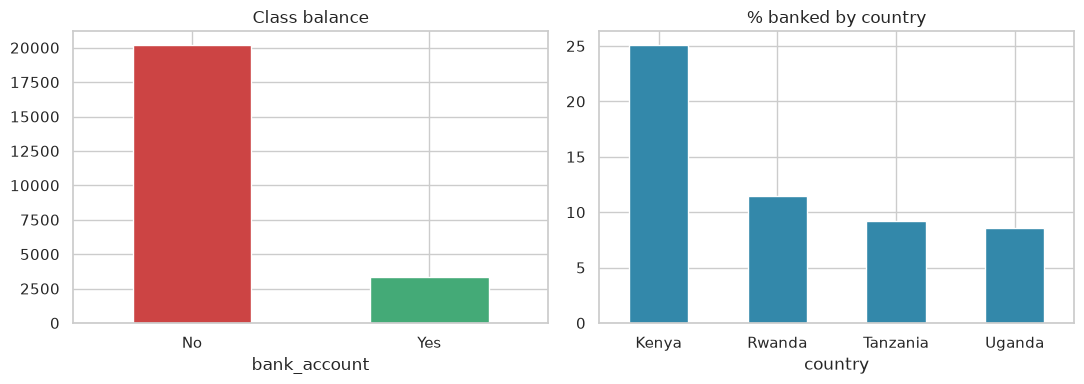

In [8]:
fig, ax = plt.subplots(1,2, figsize=(11,4))
df["bank_account"].value_counts().plot.bar(ax=ax[0], color=[NEG, ACCENT])
ax[0].set_title("Class balance"); ax[0].tick_params(axis="x", rotation=0)
df.groupby("country")["bank_account"].apply(lambda s:(s=="Yes").mean()*100).plot.bar(
    ax=ax[1], color=PRIMARY); ax[1].set_title("% banked by country")
ax[1].tick_params(axis="x", rotation=0); plt.tight_layout(); plt.show()

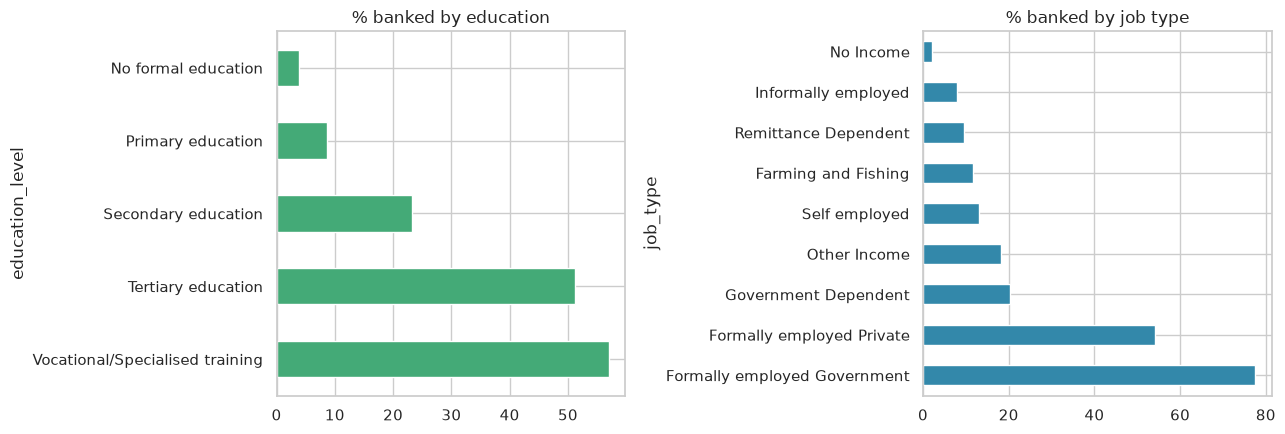

In [9]:
fig, ax = plt.subplots(1,2, figsize=(13,4.5))
rate_by("education_level").plot.barh(ax=ax[0], color=ACCENT); ax[0].set_title("% banked by education")
rate_by("job_type").plot.barh(ax=ax[1], color=PRIMARY); ax[1].set_title("% banked by job type")
plt.tight_layout(); plt.show()

## Step 4  -  Objectives

This project pursues two complementary data-mining objectives on the same dataset:

1. **Supervised objective (classification / prediction):** predict whether an individual has a bank account (target variable `Has a Bank account`) and compare **four** classification algorithms grouped into two learning paradigms:
   - *Classical machine learning:* Linear Discriminant Analysis (LDA), Quadratic Discriminant Analysis (QDA), and K-Nearest Neighbors (KNN).
   - *Deep learning:* a Neural Network implemented with TensorFlow/Keras.
2. **Unsupervised objective (clustering):** discover financial-inclusion segments in the population using K-Means.
3. **Improvement objective:** address the class imbalance and measure whether model performance improves.

Using four supervised algorithms - three classical and one deep-learning - together with K-Means clustering, this project satisfies the exam requirement to apply *at least three different learning algorithms, including deep learning*, as well as the separate clustering requirement.

## Step 5  -  Modeling

### Learning approaches used
To satisfy the exam requirement of *at least three different learning algorithms, including deep learning*, this project implements **four** supervised classification algorithms, deliberately drawn from two distinct learning paradigms:

**Classical machine learning**
- **Linear Discriminant Analysis (LDA)** - linear probabilistic classifier.
- **Quadratic Discriminant Analysis (QDA)** - quadratic probabilistic classifier.
- **K-Nearest Neighbors (KNN)** - instance-based, distance-driven classifier.

**Deep learning**
- **Neural Network (TensorFlow/Keras)** - a feed-forward deep-learning model that predicts the target variable `Has a Bank account`. This is the model that specifically fulfils the *deep-learning* component of the requirement.

All four models address the same supervised task (predicting bank-account ownership) and are evaluated on identical metrics, allowing a direct comparison between classical and deep-learning approaches. The unsupervised **K-Means** algorithm (later section) additionally fulfils the clustering requirement.

### Preprocessing: encode + split + scale
One-hot encode categoricals, stratified 80/20 split, standardize (KNN, the Neural Network and the discriminant models are all scale-sensitive).

In [10]:
y = (df["bank_account"]=="Yes").astype(int)
X = pd.get_dummies(df.drop(columns=["bank_account"]),
                   columns=cat_cols, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print("Train:", X_train_s.shape, "Test:", X_test_s.shape)

Train: (18790, 29) Test: (4698, 29)


In [11]:
results = {}
def evaluate(name, y_pred, y_prob, store):
    store[name] = {
        "Accuracy": accuracy_score(y_test,y_pred),
        "Precision": precision_score(y_test,y_pred,zero_division=0),
        "Recall": recall_score(y_test,y_pred,zero_division=0),
        "F1": f1_score(y_test,y_pred,zero_division=0),
        "ROC_AUC": roc_auc_score(y_test,y_prob)}
    print(f"{name}: F1={store[name]['F1']:.3f}  AUC={store[name]['ROC_AUC']:.3f}")
    return store

### 5.1 Linear Discriminant Analysis (LDA)

In [12]:
lda = LinearDiscriminantAnalysis().fit(X_train_s, y_train)
evaluate("LDA", lda.predict(X_test_s), lda.predict_proba(X_test_s)[:,1], results);

LDA: F1=0.491  AUC=0.856


### 5.2 Quadratic Discriminant Analysis (QDA)
`reg_param=0.5` regularizes the per-class covariance matrix, which would otherwise be near-singular given the many sparse one-hot columns.

In [13]:
qda = QuadraticDiscriminantAnalysis(reg_param=0.5).fit(X_train_s, y_train)
evaluate("QDA", qda.predict(X_test_s), qda.predict_proba(X_test_s)[:,1], results);

QDA: F1=0.500  AUC=0.843


### 5.3 K-Nearest Neighbors (KNN)

In [14]:
knn = KNeighborsClassifier(n_neighbors=15).fit(X_train_s, y_train)
evaluate("KNN", knn.predict(X_test_s), knn.predict_proba(X_test_s)[:,1], results);

KNN: F1=0.476  AUC=0.842


### 5.4 Neural Network  -  Deep-Learning Model (TensorFlow/Keras)

This is the **deep-learning** model of the project, implemented with **TensorFlow/Keras**. It is a feed-forward (fully connected) neural network with two hidden layers (64 and 32 ReLU units) and dropout regularisation, ending in a single sigmoid output neuron. As a supervised classifier it predicts the probability that an individual has a bank account (target `Has a Bank account`) and is evaluated on the same metrics as the classical models (LDA, QDA, KNN), so its performance can be compared directly against them. The Neural Network is the component that satisfies the exam's requirement to include a deep-learning algorithm.

In [15]:
def build_nn(d):
    m = Sequential([Input(shape=(d,)),
                    Dense(64,activation="relu"), Dropout(0.3),
                    Dense(32,activation="relu"), Dropout(0.2),
                    Dense(1,activation="sigmoid")])
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m
nn = build_nn(X_train_s.shape[1])
hist = nn.fit(X_train_s, y_train, validation_split=0.15,
              epochs=30, batch_size=64, verbose=0)
nn_prob = nn.predict(X_test_s, verbose=0).ravel()
evaluate("Neural Network", (nn_prob>=0.5).astype(int), nn_prob, results);

Neural Network: F1=0.478  AUC=0.872


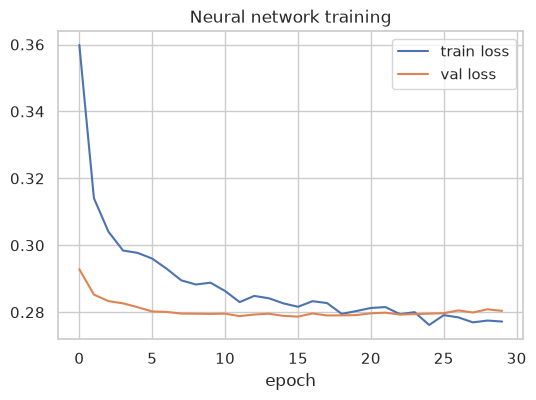

In [16]:
plt.figure(figsize=(6,4))
plt.plot(hist.history["loss"], label="train loss")
plt.plot(hist.history["val_loss"], label="val loss")
plt.title("Neural network training"); plt.xlabel("epoch"); plt.legend(); plt.show()

## Step 6  -  Evaluation & Comparison
Because the target is imbalanced (~86% unbanked), **accuracy is misleading**; F1 and ROC-AUC are the decisive metrics.

In [17]:
baseline = pd.DataFrame(results).T.round(4)
baseline

,Accuracy,Precision,Recall,F1,ROC_AUC
LDA,0.8846,0.6493,0.3943,0.4906,0.8556
QDA,0.8661,0.5277,0.4743,0.4996,0.8432
KNN,0.8872,0.6886,0.3640,0.4763,0.8421
Neural Network,0.8889,0.7071,0.3610,0.4780,0.8715


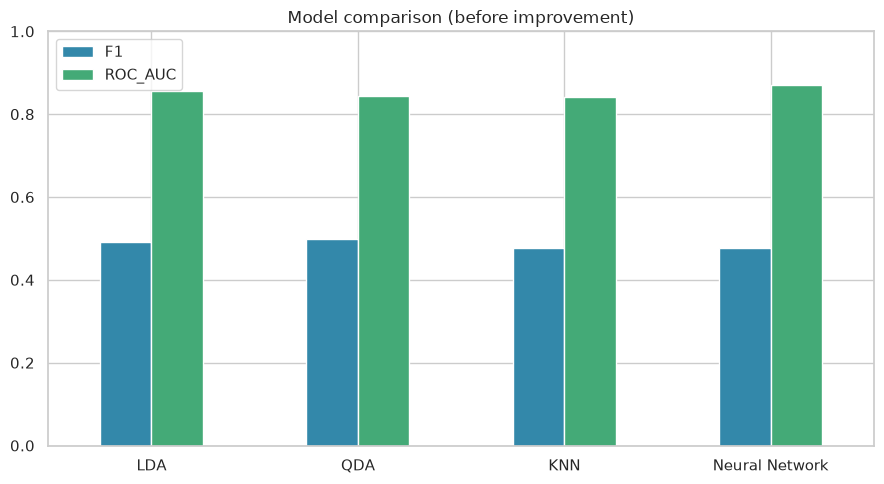

In [18]:
ax = baseline[["F1","ROC_AUC"]].plot.bar(figsize=(9,5), color=[PRIMARY, ACCENT])
ax.set_title("Model comparison (before improvement)"); ax.set_ylim(0,1)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

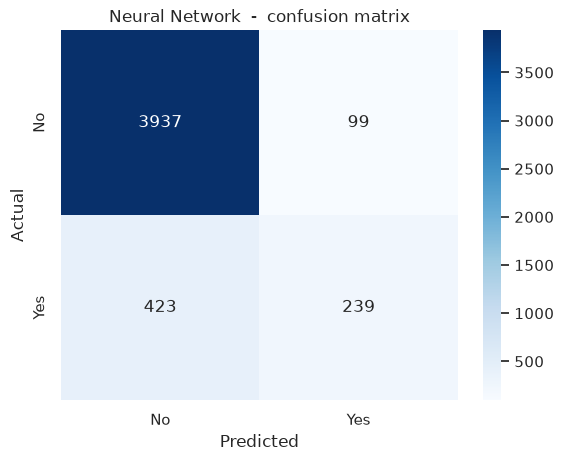

In [19]:
# Confusion matrix of the best-AUC model (Neural Network)
cm = confusion_matrix(y_test, (nn_prob>=0.5).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No","Yes"], yticklabels=["No","Yes"])
plt.title("Neural Network  -  confusion matrix"); plt.ylabel("Actual"); plt.xlabel("Predicted"); plt.show()

## Step 7  -  Improving Performance (SMOTE)
The minority class (has account) is under-represented, so models favour predicting "No" and miss true account-holders (low recall). **SMOTE** synthesises minority examples to balance the training set. Applied to the **training data only** to avoid leakage.

In [20]:
sm = SMOTE(random_state=RANDOM_SEED)
X_res, y_res = sm.fit_resample(X_train_s, y_train)
print("Balanced training set:", X_res.shape, np.bincount(y_res))

improved = {}
lda2 = LinearDiscriminantAnalysis().fit(X_res, y_res)
evaluate("LDA", lda2.predict(X_test_s), lda2.predict_proba(X_test_s)[:,1], improved)
qda2 = QuadraticDiscriminantAnalysis(reg_param=0.5).fit(X_res, y_res)
evaluate("QDA", qda2.predict(X_test_s), qda2.predict_proba(X_test_s)[:,1], improved)
knn2 = KNeighborsClassifier(n_neighbors=15).fit(X_res, y_res)
evaluate("KNN", knn2.predict(X_test_s), knn2.predict_proba(X_test_s)[:,1], improved)
nn2 = build_nn(X_res.shape[1])
nn2.fit(X_res, y_res, validation_split=0.15, epochs=30, batch_size=64, verbose=0)
nn2_prob = nn2.predict(X_test_s, verbose=0).ravel()
evaluate("Neural Network", (nn2_prob>=0.5).astype(int), nn2_prob, improved);

Balanced training set: (32286, 29) [16143 16143]
LDA: F1=0.505  AUC=0.862
QDA: F1=0.524  AUC=0.843
KNN: F1=0.474  AUC=0.835
Neural Network: F1=0.540  AUC=0.867


Neural Network: F1=0.545  AUC=0.870


## Step 8  -  Before vs After Comparison
Compare F1 and recall before and after SMOTE to confirm whether performance improved.

In [21]:
imp = pd.DataFrame(improved).T.round(4)
comp = pd.concat({"Before":baseline[["Recall","F1","ROC_AUC"]],
                  "After":imp[["Recall","F1","ROC_AUC"]]}, axis=1)
comp

Before                   After                
                Recall      F1 ROC_AUC  Recall      F1 ROC_AUC
LDA             0.3943  0.4906  0.8556  0.7372  0.5054  0.8625
QDA             0.4743  0.4996  0.8432  0.6073  0.5245  0.8434
KNN             0.3640  0.4763  0.8421  0.7462  0.4739  0.8349
Neural Network  0.3610  0.4780  0.8715  0.6782  0.5400  0.8673

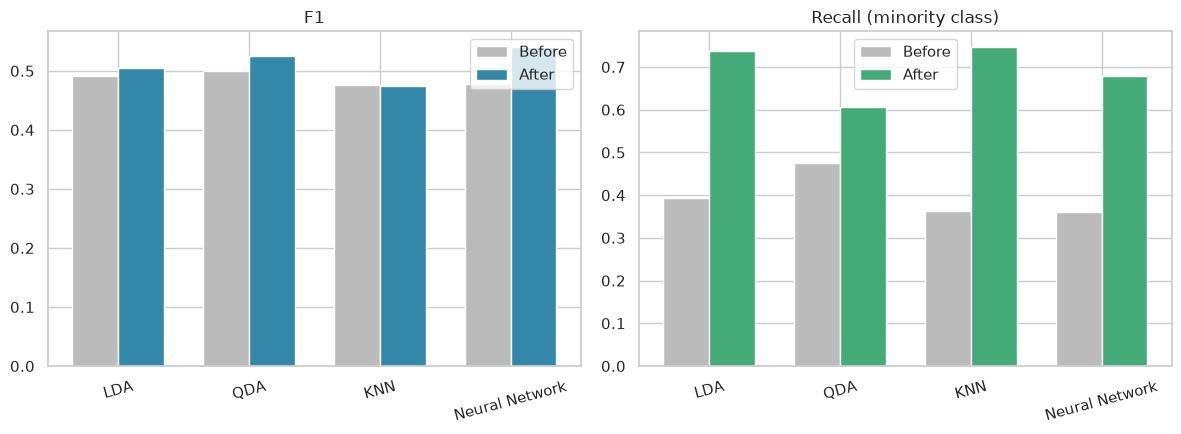

In [22]:
fig, ax = plt.subplots(1,2, figsize=(12,4.5))
x = np.arange(len(baseline)); w=0.35
ax[0].bar(x-w/2, baseline["F1"], w, label="Before", color=MUTED)
ax[0].bar(x+w/2, imp["F1"], w, label="After", color=PRIMARY)
ax[0].set_xticks(x); ax[0].set_xticklabels(baseline.index, rotation=15); ax[0].set_title("F1"); ax[0].legend()
ax[1].bar(x-w/2, baseline["Recall"], w, label="Before", color=MUTED)
ax[1].bar(x+w/2, imp["Recall"], w, label="After", color=ACCENT)
ax[1].set_xticks(x); ax[1].set_xticklabels(baseline.index, rotation=15); ax[1].set_title("Recall (minority class)"); ax[1].legend()
plt.tight_layout(); plt.show()

**Interpretation.** SMOTE sharply increases **recall** for every model  -  the models now identify far more true account-holders  -  and improves **F1** for most, at some cost to precision. This is the desired trade-off when the goal is to find financially-included (or excludable) individuals rather than to maximise raw accuracy.

## Step 5 (applied)  -  Single Prediction with the Deep-Learning Model

To demonstrate the trained model in practice, we take one hypothetical individual, pass them through the **same preprocessing pipeline** used for training (one-hot encoding aligned to the training columns, then standardisation), and use the deep-learning **Neural Network** (the SMOTE-trained model `nn2`) to predict whether that person has a bank account (`Has a Bank account`). This confirms the model can score a brand-new, unseen record end to end.

In [23]:
# --- Single prediction on one hypothetical (mock) individual ---
# 1. Define one new person using valid category values from the dataset
new_person = {
    "country": "Kenya",
    "year": 2018,
    "location_type": "Urban",
    "cellphone_access": "Yes",
    "household_size": 4,
    "age": 30,
    "gender": "Female",
    "relationship_with_head": "Head of Household",
    "marital_status": "Married/Living together",
    "education_level": "Tertiary education",
    "job_type": "Formally employed Private",
}
new_df = pd.DataFrame([new_person])

# 2. Apply the SAME preprocessing as training:
#    One-hot encode WITHOUT drop_first, then align to the training columns (X.columns).
#    Reindexing to X.columns reproduces the training encoding exactly: each reference
#    category that was dropped during training is naturally represented as all-zeros,
#    while categories present in the profile map to their corresponding 1s.
new_enc = pd.get_dummies(new_df, columns=cat_cols)
new_enc = new_enc.reindex(columns=X.columns, fill_value=0)   # align to training features
new_scaled = scaler.transform(new_enc)                        # same scaler as training

# 3. Predict with the deep-learning Neural Network (SMOTE-trained model)
prob = float(nn2.predict(new_scaled, verbose=0).ravel()[0])
prediction = "Yes (likely has a bank account)" if prob >= 0.5 else "No (likely unbanked)"

print("Input profile:")
for k, v in new_person.items():
    print(f"  {k:>22}: {v}")
print("\nPredicted probability of having a bank account: {:.1%}".format(prob))
print("Model decision (threshold 0.5):", prediction)

Input profile:
                 country: Kenya
                    year: 2018
           location_type: Urban
        cellphone_access: Yes
          household_size: 4
                     age: 30
                  gender: Female
  relationship_with_head: Head of Household
          marital_status: Married/Living together
         education_level: Tertiary education
                job_type: Formally employed Private

Predicted probability of having a bank account: 97.4%
Model decision (threshold 0.5): Yes (likely has a bank account)


## Unsupervised  -  K-Means Clustering

While LDA, QDA, KNN and the Neural Network perform **supervised** classification (predicting `Has a Bank account`), K-Means performs the project's **unsupervised** task. The target is dropped and respondents are clustered on their demographic features to reveal financial-inclusion segments. The number of clusters *k* is chosen using the elbow and silhouette methods.

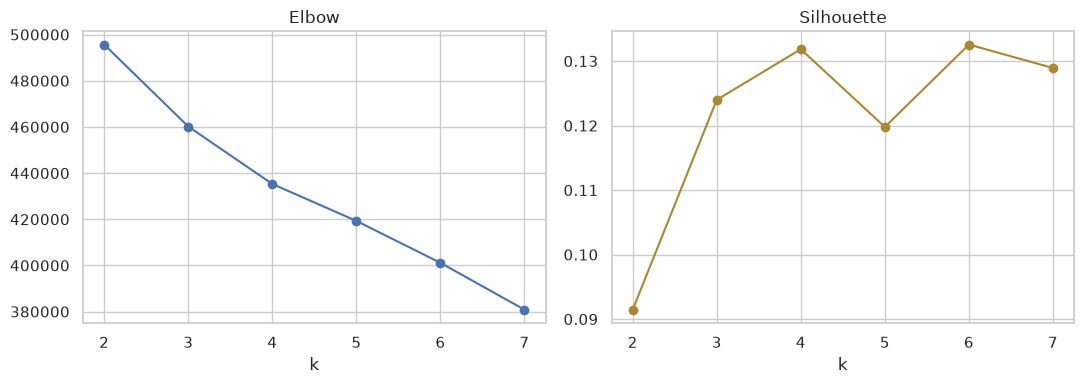

In [24]:
Ks = range(2,8); inertias=[]; sils=[]
for k in Ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10).fit(X_train_s)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_train_s, km.labels_, sample_size=5000, random_state=RANDOM_SEED))
fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].plot(list(Ks), inertias, "o-"); ax[0].set_title("Elbow"); ax[0].set_xlabel("k")
ax[1].plot(list(Ks), sils, "o-", color=WARN); ax[1].set_title("Silhouette"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.show()

In [25]:
k = 4
km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10).fit(X_train_s)
prof = df.loc[X_train.index].copy(); prof["cluster"] = km.labels_
summary = prof.groupby("cluster").agg(
    size=("cluster","size"),
    bank_rate=("bank_account", lambda s:round((s=="Yes").mean()*100,1)),
    mean_age=("age","mean"),
    country=("country", lambda s:s.mode()[0]),
    location=("location_type", lambda s:s.mode()[0]),
    education=("education_level", lambda s:s.mode()[0]),
    job=("job_type", lambda s:s.mode()[0])).round(1)
summary

,size,bank_rate,mean_age,country,location,education,job
cluster,,,,,,,
0,5553,21.0,36.2,Kenya,Rural,Primary education,Self employed
1,2175,9.1,60.8,Rwanda,Rural,No formal education,Farming and Fishing
2,5979,11.8,36.1,Rwanda,Rural,Primary education,Farming and Fishing
3,5083,11.3,35.7,Tanzania,Urban,Primary education,Self employed


**Segment interpretation (typical run).**
- **Older rural, no formal education, farming** -> lowest account ownership (~9%): the financially-excluded segment.
- **Kenyan self-employed** -> highest ownership (~21%): the most-included segment.
- Two mixed rural/urban primary-educated segments in between.

The clusters recover a clear inclusion gradient without ever seeing the target, and align with the supervised findings.

## Conclusion
- Four classifiers were compared; the **Neural Network** achieved the best ROC-AUC and, after **SMOTE**, the discriminant models and NN reached the best F1/recall balance.
- **SMOTE improved recall and F1** across the board  -  performance improved (Step 8 confirmed).
- **K-Means** revealed interpretable inclusion segments consistent with the supervised drivers (education, job type, cellphone access, country).

## References
1. Mokua, E. *Financial Dataset* (Financial Inclusion in East Africa), Kaggle. https://www.kaggle.com/datasets/enockmokua/financial-dataset/data
2. FSD Africa / FinScope household surveys  -  Kenya, Rwanda, Tanzania, Uganda (2016-2018).
3. Chawla, N. et al. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *JAIR*, 16, 321-357.
4. Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825-2830.
5. Abadi, M. et al. (2016). TensorFlow: A System for Large-Scale Machine Learning.